# Mecanismos de ausência

**Tema:** Preparação de Dados › Dados Faltantes e Outliers

Este notebook constrói, de propósito, os três mecanismos de Rubin (MCAR, MAR,
MNAR) a partir dos **mesmos dados completos** — porque na vida real nunca
vemos os dados completos, só a versão com buracos. Ter o "antes" e o "depois"
lado a lado é o que torna possível ver o efeito de cada mecanismo com
clareza.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(10)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Os dados completos (o "chão de verdade" que nunca vemos na prática)

In [2]:
n = 3000
idade = rng.normal(40, 12, n).clip(18, 80)
renda = (2000 + 120 * idade + rng.normal(0, 1500, n)).clip(800, None)

completo = pd.DataFrame({"idade": idade, "renda": renda})
print(completo.describe().round(1))

        idade    renda
count  3000.0   3000.0
mean     39.6   6748.3
std      11.5   2037.1
min      18.0    800.0
25%      31.3   5373.1
50%      39.3   6719.4
75%      47.2   8140.7
max      80.0  13865.4


## 2. Três versões da mesma coluna, cada uma com um mecanismo diferente

Vamos apagar `renda` de três formas diferentes, mantendo `idade` sempre
observada.

In [3]:
p_ausencia = 0.30

# MCAR: a moeda decide sozinha, sem depender de nada
mascara_mcar = rng.random(n) < p_ausencia

# MAR: a ausência depende de IDADE (observada) — pessoas mais velhas
# respondem menos.
prob_mar = 0.10 + 0.5 * (idade - idade.min()) / (idade.max() - idade.min())
mascara_mar = rng.random(n) < prob_mar

# MNAR: a ausência depende da PRÓPRIA RENDA — quem ganha muito omite.
limiar_renda = np.quantile(renda, 0.80)
prob_mnar = np.where(renda > limiar_renda, 0.65, 0.15)
mascara_mnar = rng.random(n) < prob_mnar

dados = completo.copy()
dados["renda_mcar"] = renda.copy()
dados["renda_mar"] = renda.copy()
dados["renda_mnar"] = renda.copy()
dados.loc[mascara_mcar, "renda_mcar"] = np.nan
dados.loc[mascara_mar, "renda_mar"] = np.nan
dados.loc[mascara_mnar, "renda_mnar"] = np.nan

for col in ["renda_mcar", "renda_mar", "renda_mnar"]:
    print(f"{col}: {dados[col].isna().mean():.1%} de nulos")

renda_mcar: 29.2% de nulos
renda_mar: 27.5% de nulos
renda_mnar: 25.1% de nulos


## 3. Diagnóstico: a ausência se associa com variáveis observadas?

Regressão logística prevendo "é nulo?" a partir de `idade` — o teste prático
mais simples para distinguir MCAR de MAR.

In [4]:
for col in ["renda_mcar", "renda_mar"]:
    eh_nulo = dados[col].isna().astype(int)
    modelo = LogisticRegression().fit(dados[["idade"]], eh_nulo)
    coef = modelo.coef_[0][0]
    # pseudo-R2 simplificado: quão bem idade prevê a ausência
    from sklearn.metrics import roc_auc_score
    prob_prevista = modelo.predict_proba(dados[["idade"]])[:, 1]
    auc = roc_auc_score(eh_nulo, prob_prevista)
    print(f"{col:<12s}  coef(idade) = {coef:+.4f}   AUC prevendo nulo a partir "
          f"de idade = {auc:.3f}")

print("\nMCAR: coeficiente perto de zero, AUC perto de 0.5 -> idade NÃO prevê ausência.")
print("MAR : coeficiente e AUC nitidamente distantes de zero/0.5 -> idade PREVÊ ausência.")

renda_mcar    coef(idade) = +0.0021   AUC prevendo nulo a partir de idade = 0.506
renda_mar     coef(idade) = +0.0341   AUC prevendo nulo a partir de idade = 0.613

MCAR: coeficiente perto de zero, AUC perto de 0.5 -> idade NÃO prevê ausência.
MAR : coeficiente e AUC nitidamente distantes de zero/0.5 -> idade PREVÊ ausência.


## 4. O caso MNAR: o teste acima não vê nada de errado

Isso é o ponto mais importante do notebook. MNAR depende do **próprio valor
ausente**, não de variáveis observadas — então testar contra `idade` não
vai, necessariamente, denunciar o problema.

In [5]:
eh_nulo_mnar = dados["renda_mnar"].isna().astype(int)
modelo_mnar = LogisticRegression().fit(dados[["idade"]], eh_nulo_mnar)
from sklearn.metrics import roc_auc_score
auc_mnar = roc_auc_score(eh_nulo_mnar,
                         modelo_mnar.predict_proba(dados[["idade"]])[:, 1])
print(f"renda_mnar   coef(idade) = {modelo_mnar.coef_[0][0]:+.4f}   AUC = {auc_mnar:.3f}")
print("\nEsse teste sozinho pode parecer 'quase MCAR' — porque idade não é a")
print("causa da ausência aqui. Só comparando com o valor REAL de renda (que só")
print("temos porque simulamos) é que o mecanismo MNAR fica visível:")

media_observada = dados["renda_mnar"].dropna().mean()
media_real_dos_que_faltam = renda[mascara_mnar].mean()
print(f"\nmédia de renda ENTRE OS OBSERVADOS : {media_observada:.0f}")
print(f"média de renda ENTRE OS QUE FALTAM  : {media_real_dos_que_faltam:.0f}")
print("-> os que faltam ganham sistematicamente MAIS. Isso é invisível olhando")
print("   só para os dados observados — só aparece porque simulamos o 'chão de verdade'.")

renda_mnar   coef(idade) = +0.0485   AUC = 0.651

Esse teste sozinho pode parecer 'quase MCAR' — porque idade não é a
causa da ausência aqui. Só comparando com o valor REAL de renda (que só
temos porque simulamos) é que o mecanismo MNAR fica visível:

média de renda ENTRE OS OBSERVADOS : 6334
média de renda ENTRE OS QUE FALTAM  : 7982
-> os que faltam ganham sistematicamente MAIS. Isso é invisível olhando
   só para os dados observados — só aparece porque simulamos o 'chão de verdade'.


## 5. O efeito prático: análise de caso completo (listwise deletion) enviesa MNAR

média VERDADEIRA (dados completos, nunca disponível na prática): 6748.3

MCAR: média em casos completos = 6722.2   viés = -0.39%
MAR: média em casos completos = 6559.5   viés = -2.80%
MNAR: média em casos completos = 6334.3   viés = -6.13%


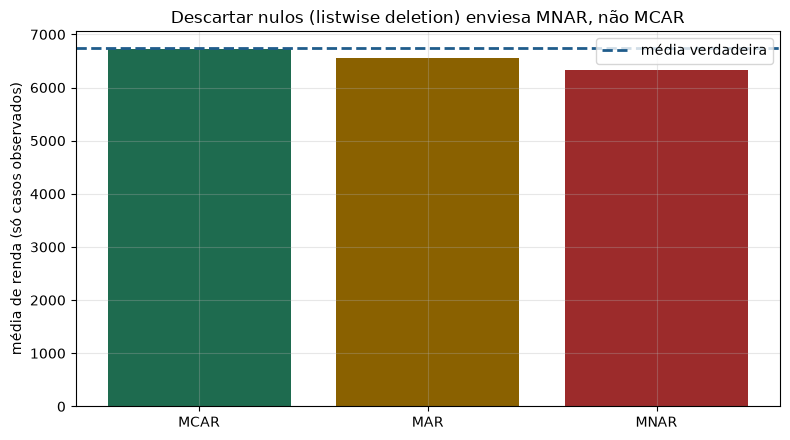

In [6]:
resultado = {}
for col, mecanismo in [("renda_mcar", "MCAR"), ("renda_mar", "MAR"), ("renda_mnar", "MNAR")]:
    media_caso_completo = dados[col].dropna().mean()
    resultado[mecanismo] = media_caso_completo

media_verdadeira = renda.mean()
print(f"média VERDADEIRA (dados completos, nunca disponível na prática): "
      f"{media_verdadeira:.1f}\n")
for mecanismo, media in resultado.items():
    vies = (media - media_verdadeira) / media_verdadeira
    print(f"{mecanismo}: média em casos completos = {media:.1f}   "
          f"viés = {vies:+.2%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
mecanismos = list(resultado.keys())
valores = list(resultado.values())
ax.bar(mecanismos, valores, color=[VERDE, AMBAR, VERMELHO])
ax.axhline(media_verdadeira, color=AZUL, lw=2, ls="--", label="média verdadeira")
ax.set_ylabel("média de renda (só casos observados)")
ax.set_title("Descartar nulos (listwise deletion) enviesa MNAR, não MCAR")
ax.legend(); plt.tight_layout(); plt.show()

**A lição central:** descartar linhas com nulo (`dropna()`) é **inofensivo**
sob MCAR (a média dos casos completos continua sem viés, só perde precisão
por ter menos dados) e é **perigoso** sob MNAR (a média fica sistematicamente
errada, porque os que faltam não são uma amostra aleatória dos que existem).
MAR fica no meio: descartar sem usar as variáveis associadas à ausência
introduz viés menor, mas ainda existente.

## O que levar deste notebook

- MCAR, MAR e MNAR não são rótulos acadêmicos — eles preveem exatamente o
  viés que aparece se você tratar a ausência da forma errada.
- Testar se "é nulo" se associa com variáveis observadas detecta MAR, mas
  **não detecta MNAR** — MNAR depende do próprio valor ausente, invisível por
  definição.
- `dropna()` é seguro sob MCAR e enviesado sob MNAR. Entre os dois, o
  julgamento de negócio sobre o processo de coleta pesa mais que qualquer
  teste estatístico.

→ Próximo: **Estratégias de imputação**, incluindo o que fazer quando o
mecanismo não é MCAR.